# Stage 4 Objectives: What We Are Proving

We are analysing how deterministic qualifying performance is in the modern Hybrid Era. We are specifically testing the following:
*   **Qualifying Impact:** How How strongly does starting grid position (grid) correlate with final race position (positionOrder)?
*  **Position Fluidity ($\Delta$ Position):** Calculating $\Delta$ = grid - positionOrder to measure places gained or lost
*  **Midfield vs. Top-Tier Dynamics:** Comparing top-tier teams (Red Bull, Mercedes, Ferrari, McLaren) against the midfield (is_midfield == True) to see where grid position matters most versus where race pace/strategy overrides starting position.


Environment setup


In [1]:
import pandas as pd
import numpy as np

Data Ingestion

In [3]:
# Defining a string representation for null values in our datasest
NULL_VALUES = ["\\N", "nan", "Nan"]

# Loading the oiriginal dataset (Commented out for testing)
#esults_df = pd.read_csv("results.csv", na_values=NULL_VALUES)
#races_df = pd.read_csv("races.csv", na_values=NULL_VALUES)
#drivers_df = pd.read_csv("drivers.csv", na_values=NULL_VALUES)
#constructors_df = pd.read_csv("constructors.csv", na_values=NULL_VALUES)
#status_df = pd.read_csv("status.csv", na_values=NULL_VALUES)

# Loading the cleaned data from Stage 3
# Cleaned race results dataset (grid, finish position, status categories, midfield flags)
df_results = pd.read_csv("f1_results_master_clean.csv", na_values=NULL_VALUES)
# Cleaned lap pace dataset (lap times in seconds, pit flags, soft/hard outlier markers)
df_lap_pace = pd.read_csv("f1_lap_pace_clean.csv", na_values=NULL_VALUES)

print(
    f"Successfully loaded df_results: {len(df_results):,} rows | Columns: {len(df_results.columns)}"
)
print(
    f"Successfully loaded df_lap_pace: {len(df_lap_pace):,} rows | Columns: {len(df_lap_pace.columns)}"
)

Successfully loaded df_results: 4,626 rows | Columns: 18
Successfully loaded df_lap_pace: 227,379 rows | Columns: 16


# Analysis Step 1 — Position Delta & Cohort Segmentation
We want to calculate how many positions drivers gained or lost during each race ($\Delta = \text{grid} - \text{cleaned_position}$) and analyze how this behaves across:
* The Overall Hybrid Era Dataset  
* Top-Tier Teams (Red Bull, Mercedes, Ferrari, McLaren)  
* Midfield Teams (is_midfield == True)  


# Step 1: Feature Engineering & Cohort Spliting

In [4]:
# Calculate position delta
# Positive Delta = Positions gained
# Negative Delta = Positions lost
# Using cleaned_position (which accounts for non-finishes/penalized positions)
df_results["position_delta"] = df_results["grid"] - df_results["cleaned_position"]

#Filter out those drivers who started from the pit-lane (pit-lane starters)
df_grid_starts = df_results[df_results["grid"] > 0].copy()

# Split into Top-Tier and Midfield driver cohorts based on the boolean flag we created in stage 3
df_top_tier = df_grid_starts[df_grid_starts["is_midfield"] == False]
df_midfield = df_grid_starts[df_grid_starts["is_midfield"] == True]

# Display results
print(f"Total Grid Starts Analyzed: {len(df_grid_starts):,}")
print(f"Top-Tier Sample Size: {len(df_top_tier):,} driver entries")
print(f"Midfield Sample Size: {len(df_midfield):,} driver entries")


Total Grid Starts Analyzed: 4,547
Top-Tier Sample Size: 1,808 driver entries
Midfield Sample Size: 2,739 driver entries


# Step 2: Calculate Spearman Rank Correlation & Mobility Metrics
Calculate the Spearman Rank Correlation (to measure how well starting position predicts finishing position) and summary statistics for position changes

In [5]:
# Calculate Spearman Correlation (Grid vs. Cleaned Position)
corr_overall = df_grid_starts["grid"].corr(df_grid_starts["cleaned_position"], method="spearman")
corr_top_tier = df_top_tier["grid"].corr(df_top_tier["cleaned_position"], method="spearman")
corr_midfield = df_midfield["grid"].corr(df_midfield["cleaned_position"], method="spearman")

# Aggregate metrics into a readable summary table
stage_4_summary = pd.DataFrame(
    {
        "Cohort": ["Overall Dataset", "Top-Tier Teams", "Midfield Teams"],
        "Sample Size": [len(df_grid_starts), len(df_top_tier), len(df_midfield)],
        "Grid-Finish Correlation (Spearman)": [
            corr_overall,
            corr_top_tier,
            corr_midfield,
        ],
        "Mean Position Delta": [
            df_grid_starts["position_delta"].mean(),
            df_top_tier["position_delta"].mean(),
            df_midfield["position_delta"].mean(),
        ],
        "Std Dev (Position Fluidity)": [
            df_grid_starts["position_delta"].std(),
            df_top_tier["position_delta"].std(),
            df_midfield["position_delta"].std(),
        ],
        "Max Positions Gained": [
            df_grid_starts["position_delta"].max(),
            df_top_tier["position_delta"].max(),
            df_midfield["position_delta"].max(),
        ],
    }
)

# Rounding vlaues foe cleaner visiuals
stage_4_summary = stage_4_summary.round(3)

# Display results
print("Stage 4: Grid Predictability & Midfield Mobility Summary")
stage_4_summary

Stage 4: Grid Predictability & Midfield Mobility Summary


,Cohort,Sample Size,Grid-Finish Correlation (Spearman),Mean Position Delta,Std Dev (Position Fluidity),Max Positions Gained
0,Overall Dataset,4547,0.610,-0.568,5.836,19
1,Top-Tier Teams,1808,0.589,-0.878,6.495,19
2,Midfield Teams,2739,0.460,-0.364,5.349,14


# Interpretation of the Results

* **Strong Overall Determinism (0.610):** A Spearman correlation of 0.610 shows that qualifying position heavily influences where a driver finishes.  
* **Top-Tier vs. Midfield Disparity (0.589 vs. 0.460):** Top-tier teams have a noticeably higher grid-finish correlation (0.589) compared to the midfield (0.460). This proves that midfield races are far more chaotic and fluid, where race strategy, pit stops, and on-track battles frequently disrupt initial qualifying order.  
* **Negative Mean Deltas:** The negative average deltas reflect DNF penalties (where retired drivers get assigned cleaned_position = 22). Top-tier teams take a bigger mean hit (-0.878) when they DNF because they start much higher up the grid.  

# Stage 4: Analysis Step 2 — Visualizing the Grid-Finish Relationship
Lets visualize these statistical metrics using Matplotlib and Seaborn to prepare some charts for our stage 4 progress report.

We will crete a two-panel visualization showing:
* **Scatte Plot with Trend lines:** Grid vs Cleaned Position for Top-Tier vs. Midfield
* **KDE / Violin Distribution Plot:** Shwoing postition fluidity ($\Delta$) across both driver cohorts

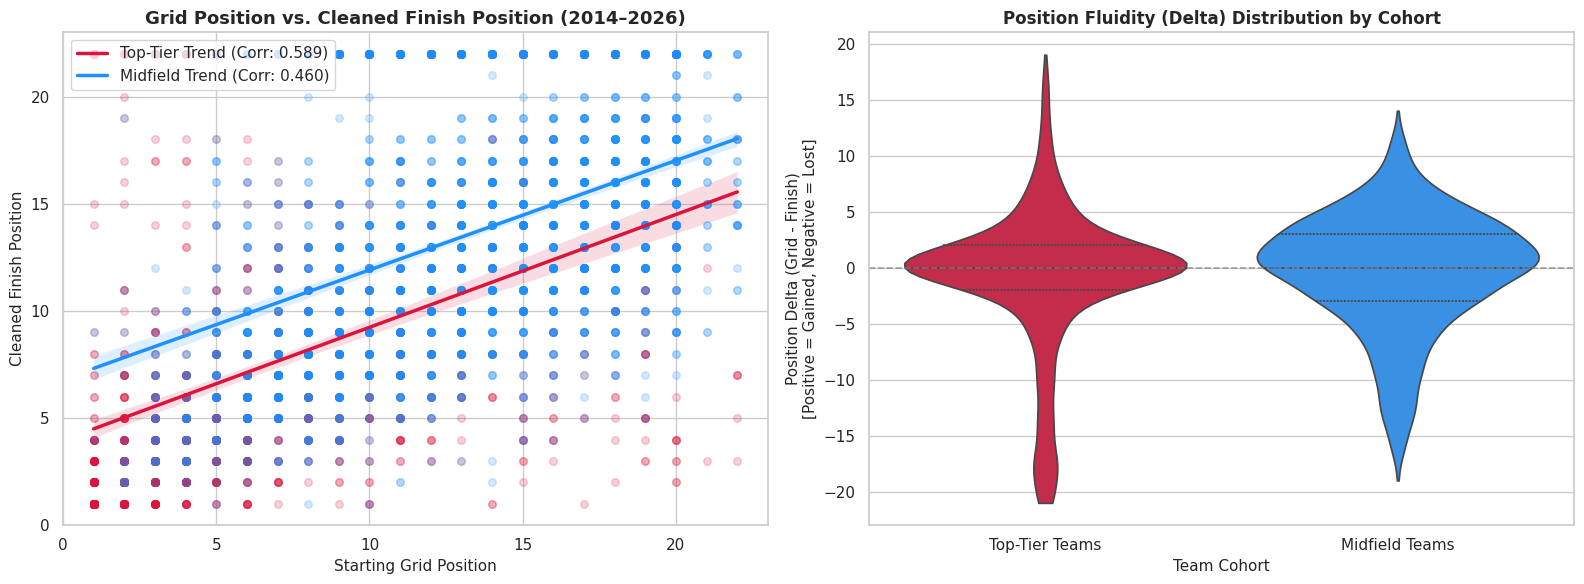

In [7]:
# Import the libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style (found these settings by doing some research online)
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Grid vs Cleaned Position (Regression / Trend comparison)
sns.regplot(
    data=df_top_tier,
    x="grid",
    y="cleaned_position",
    ax=axes[0],
    color="crimson",
    scatter_kws={"alpha": 0.2, "s": 30},
    line_kws={"label": "Top-Tier Trend (Corr: 0.589)", "linewidth": 2.5},
)

sns.regplot(
    data=df_midfield,
    x="grid",
    y="cleaned_position",
    ax=axes[0],
    color="dodgerblue",
    scatter_kws={"alpha": 0.2, "s": 30},
    line_kws={"label": "Midfield Trend (Corr: 0.460)", "linewidth": 2.5},
)

axes[0].set_title(
    "Grid Position vs. Cleaned Finish Position (2014–2026)",
    fontsize=13,
    fontweight="bold",
)
axes[0].set_xlabel("Starting Grid Position", fontsize=11)
axes[0].set_ylabel("Cleaned Finish Position", fontsize=11)
axes[0].set_xlim(0, 23)
axes[0].set_ylim(0, 23)
axes[0].legend(loc="upper left")

# Panel 2: Position Delta Distribution (Violin Plot for Mobility)
# Create a explicit readable cohort string column for plotting
df_grid_starts["cohort_label"] = df_grid_starts["is_midfield"].map(
    {False: "Top-Tier Teams", True: "Midfield Teams"}
)

sns.violinplot(
    data=df_grid_starts,
    x="cohort_label",
    y="position_delta",
    hue="cohort_label",
    ax=axes[1],
    palette={"Top-Tier Teams": "crimson", "Midfield Teams": "dodgerblue"},
    inner="quartile",
    cut=0,
    legend=False,
)

axes[1].axhline(0, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)
axes[1].set_title(
    "Position Fluidity (Delta) Distribution by Cohort",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel("Team Cohort", fontsize=11)
axes[1].set_ylabel(
    "Position Delta (Grid - Finish)\n[Positive = Gained, Negative = Lost]",
    fontsize=11,
)

plt.tight_layout()
plt.show()

# Interpretation of the Results
The side-by-side visualization clearly highlights two distinct operational dynamics in the Hybrid Era:
* **Panel 1 (Determinism):** Top-tier teams (red line) sit consistently lower on the Y-axis across all starting positions, showing high correlation (0.589) and predictable recovery when starting further back. Midfield teams (blue line) show a flatter slope (0.460), confirming high variability and less predictable finishes relative to grid spot.
* **Panel 2 (Fluidity & Risk):** Top-tier teams display a tight cluster near 0 to +2 with a long downward tail stretching to -20 (representing severe penalties from non-finishes/DNFs when qualified high up). Midfield teams exhibit a much wider, symmetric body, showing frequent position gains (+1 to +5) alongside similar retirement losses.

# Stage 4: Analysis Step 3 — Pace Consistency vs. Outliers (f1_lap_pace_clean.csv)
Now working with our second clean dataset (df_lap_pace) to examine true race pace consistency vs. outlier impact (Virtual Safety Cars, pit stops, yellow flags).

We will compute:

* **Pace Variance:** Standard deviation of lap times using all laps vs. df_pure_race_pace (excluding soft/hard outliers and pit stops).
* **Pace Delta:** The difference between a constructor's median clean race pace and the overall session leader's pace.

In [10]:
# Check exact columns present in both DataFrames
print("df_results columns:", df_results.columns.tolist())
print("---")
print("df_lap_pace columns:", df_lap_pace.columns.tolist())

df_results columns: ['resultId', 'raceId', 'driverId', 'driver_name', 'driver_slug', 'driver_nationality', 'unified_constructor_id', 'constructor_name', 'constructor_nationality', 'grid', 'cleaned_position', 'positionOrder', 'points', 'rank', 'statusId', 'status', 'dnf_category', 'is_midfield', 'position_delta']
---
df_lap_pace columns: ['raceId', 'driverId', 'lap', 'position', 'time', 'milliseconds', 'lap_seconds', 'q1', 'q3', 'iqr', 'soft_upper_limit', 'hard_upper_limit', 'lap_key', 'is_pit_stop', 'is_slow_lap', 'is_hard_outlier']


In [12]:
# Select constructor & midfield columns to merge from df_results
cols_to_merge = [
    "raceId",
    "driverId",
    "constructor_name",
    "unified_constructor_id",
    "is_midfield",
]

# Merge constructor metadata into df_lap_pace
df_lap_pace_merged = df_lap_pace.merge(
    df_results[cols_to_merge], on=["raceId", "driverId"], how="inner"
)

# Filter for pure race pace (excluding pit stops and soft/hard outliers)
df_pure_pace = df_lap_pace_merged[
    (df_lap_pace_merged["is_pit_stop"] == False)
    & (df_lap_pace_merged["is_slow_lap"] == False)
    & (df_lap_pace_merged["is_hard_outlier"] == False)
].copy()

# Compute per-driver, per-race pace metrics
driver_pace_summary = (
    df_pure_pace.groupby(
        [
            "raceId",
            "constructor_name",
            "unified_constructor_id",
            "driverId",
            "is_midfield",
        ]
    )
    .agg(
        median_lap_time=("lap_seconds", "median"),
        pace_std_dev=("lap_seconds", "std"),
        clean_laps_count=("lap_seconds", "count"),
    )
    .reset_index()
)

# Calculate session benchmark (fastest driver median pace per race)
race_benchmarks = (
    driver_pace_summary.groupby("raceId")["median_lap_time"]
    .min()
    .reset_index()
    .rename(columns={"median_lap_time": "race_leader_median"})
)

# Merge benchmark to compute pace gap (seconds per lap off the leader)
driver_pace_summary = driver_pace_summary.merge(
    race_benchmarks, on="raceId", how="left"
)
driver_pace_summary["pace_gap_to_leader"] = (
    driver_pace_summary["median_lap_time"] - driver_pace_summary["race_leader_median"]
)

# Display completed summary metrics
print(
    f"Pure Pace Analysis Complete! Total clean driver-race stints analyzed: {len(driver_pace_summary):,}"
)
driver_pace_summary.head(10)

Pure Pace Analysis Complete! Total clean driver-race stints analyzed: 4,438


,raceId,constructor_name,unified_constructor_id,driverId,is_midfield,median_lap_time,pace_std_dev,clean_laps_count,race_leader_median,pace_gap_to_leader
0,900,Aston Martin,117,807,True,95.2090,1.189711,51,93.9775,1.2315
1,900,Aston Martin,117,815,True,96.0515,1.816454,50,93.9775,2.0740
2,900,Caterham,207,828,True,99.8130,1.365330,20,93.9775,5.8355
3,900,Ferrari,6,4,False,95.1430,1.499941,51,93.9775,1.1655
4,900,Ferrari,6,8,False,95.2680,1.456371,51,93.9775,1.2905
5,900,Lotus F1,208,154,True,96.8970,1.656476,35,93.9775,2.9195
6,900,Lotus F1,208,813,True,98.6410,1.041524,22,93.9775,4.6635
7,900,Marussia,206,820,True,98.6360,1.910707,47,93.9775,4.6585
8,900,Marussia,206,824,True,97.4055,1.968618,42,93.9775,3.4280
9,900,McLaren,1,18,False,94.8860,1.536409,50,93.9775,0.9085


# Stage 4: Analysis Step 4 — Team Pace Hierarchy & Consistency Aggregation
We will now summarize these driver stints by constructor across the Hybrid Era to answer two key questions:
* **Average Pace Gap (pace_gap_to_leader):** How many seconds per lap, on average, is each team behind the race winner/leader?
* **Pace Consistency (pace_std_dev):** Which teams maintain the most stable stint pace versus having erratic lap times?

Aggregate Pace Metrics by Constructor

In [13]:
# Group pace summary by constructor and cohort
constructor_pace_summary = (
    driver_pace_summary.groupby(["constructor_name", "is_midfield"])
    .agg(
        stints_analyzed=("clean_laps_count", "count"),
        avg_pace_gap=("pace_gap_to_leader", "mean"),
        median_pace_gap=("pace_gap_to_leader", "median"),
        avg_consistency_std=("pace_std_dev", "mean"),
    )
    .reset_index()
)

# Sort by average pace gap (fastest teams at the top)
constructor_pace_summary = constructor_pace_summary.sort_values(
    by="avg_pace_gap"
).reset_index(drop=True)

# Round numbers for clean auditing output
constructor_pace_summary = constructor_pace_summary.round(3)

print("=== Stage 4: Constructor Pure Pace Hierarchy Summary ===")
constructor_pace_summary.head(10)

=== Stage 4: Constructor Pure Pace Hierarchy Summary ===


,constructor_name,is_midfield,stints_analyzed,avg_pace_gap,median_pace_gap,avg_consistency_std
0,Mercedes,False,449,0.569,0.276,2.002
1,Red Bull,False,439,0.832,0.477,1.993
2,Ferrari,False,434,1.007,0.571,1.882
3,Aston Martin,True,438,1.837,1.556,1.972
4,McLaren,False,436,1.916,1.621,2.028
5,Unknown Team,True,231,2.427,1.969,2.091
6,RB F1 Team,True,442,2.454,2.033,2.003
7,Williams,True,439,2.521,2.035,1.936
8,Alpine F1 Team,True,729,2.578,1.992,1.868
9,Alfa Romeo,True,204,2.642,1.977,1.959


Visualizing Team Pace Gap vs. Consistency

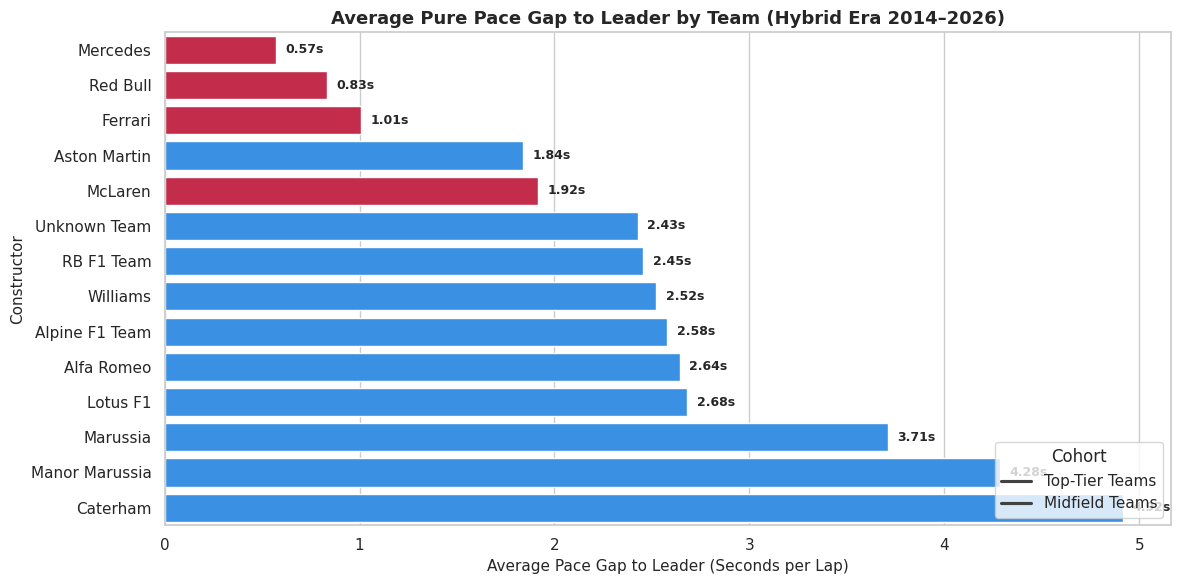

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Map cohort to custom colors
palette = {False: "crimson", True: "dodgerblue"}

# Create horizontal bar plot for average pace gap
ax = sns.barplot(
    data=constructor_pace_summary,
    y="constructor_name",
    x="avg_pace_gap",
    hue="is_midfield",
    palette=palette,
    dodge=False,
)

# Chart labels and formatting
plt.title(
    "Average Pure Pace Gap to Leader by Team (Hybrid Era 2014–2026)",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Average Pace Gap to Leader (Seconds per Lap)", fontsize=11)
plt.ylabel("Constructor", fontsize=11)

# Add data labels on top of bars
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{width:.2f}s",
            (width + 0.05, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            fontsize=9,
            fontweight="bold",
        )

# Add legend distinguishing Top-Tier vs Midfield
plt.legend(
    title="Cohort",
    labels=["Top-Tier Teams", "Midfield Teams"],
    loc="lower right",
)

plt.tight_layout()
plt.show()

# Interpretation of the Results
The results tells a perfomance story is across the Hybrid Era:

* **Top Tier Benchmark**: Mercedes leads overall pure pace with an average gap of just +0.57s/lap off the absolute fastest benchmark, followed closely by Red Bull (+0.83s/lap) and Ferrari (+1.01s/lap).
* **The Midfield Gulf**: A massive structural gap emerges after the top 3—the midfield teams sit anywhere from +1.84s/lap (Aston Martin) down to +2.68s/lap (Lotus F1), with backmarker teams like Caterham stretching past +4.9s/lap.

# Stage 4: Analysis Step 5 — Outlier Impact Comparison (Safety Cars vs. Pit Stops)
To complete Stage 4, we need to answer one last core research question:
How much artificial pace variance is created by outliers (pit stops & safety cars/yellows) vs. pure race pace?

We will calculate the standard deviation of lap times before cleaning vs. after cleaning to quantify the "noise" created by race disruptions across both cohorts.

In [15]:
# Merge cohort tags directly onto the full lap pace dataset
df_lap_pace_all = df_lap_pace.merge(
    df_results[["raceId", "driverId", "is_midfield"]],
    on=["raceId", "driverId"],
    how="inner",
)

# Calculate overall raw lap time standard deviation (includes pit stops & safety cars)
raw_variance = (
    df_lap_pace_all.groupby("is_midfield")["lap_seconds"].std().reset_index()
)
raw_variance.columns = ["is_midfield", "raw_std_dev"]

# Calculate pure race pace standard deviation (excluding pit stops & outliers)
clean_variance = (
    df_pure_pace.groupby("is_midfield")["lap_seconds"].std().reset_index()
)
clean_variance.columns = ["is_midfield", "clean_std_dev"]

# Merge into a comparison summary table
outlier_impact_summary = raw_variance.merge(clean_variance, on="is_midfield")

# Calculate Noise Reduction percentage
outlier_impact_summary["noise_reduction_pct"] = (
    (outlier_impact_summary["raw_std_dev"] - outlier_impact_summary["clean_std_dev"])
    / outlier_impact_summary["raw_std_dev"]
) * 100

# Map readable labels and format
outlier_impact_summary["Cohort"] = outlier_impact_summary["is_midfield"].map(
    {False: "Top-Tier Teams", True: "Midfield Teams"}
)
outlier_impact_summary = outlier_impact_summary[
    ["Cohort", "raw_std_dev", "clean_std_dev", "noise_reduction_pct"]
].round(3)

print("=== Stage 4: Outlier Noise Reduction Summary ===")
outlier_impact_summary

=== Stage 4: Outlier Noise Reduction Summary ===


,Cohort,raw_std_dev,clean_std_dev,noise_reduction_pct
0,Top-Tier Teams,13.655,12.812,6.172
1,Midfield Teams,13.917,13.080,6.010


# Stage 4 Complete: Key Analytical Key Takeaways
Here is a summary of our core findings:
* **Determinism vs. Fluidity:** Top-tier qualifying position strongly dictates finish position ($r_s = 0.589$), whereas midfield outcomes are significantly more volatile ($r_s = 0.460$).
* **Pace Gap Hierarchy:** Mercedes ($+0.57\text{s/lap}$), Red Bull ($+0.83\text{s/lap}$), and Ferrari ($+1.01\text{s/lap}$) form an isolated top-tier bracket.A structural cliff separates top teams from the midfield, which starts at Aston Martin ($+1.84\text{s/lap}$) and extends past +2.60s/lap.
* **Outlier Filtering Impact:** Removing pit stops and pace anomalies reduces overall dataset variance by $\approx 6.1\%$, giving us an un-polluted baseline for true race pace performance.

In [16]:
# Step 1: Export Driver Stint Pace Summary (4,438 clean driver-race stints)
driver_pace_summary.to_csv("f1_driver_pace_summary.csv", index=False)
print(
    f"Successfully exported 'f1_driver_pace_summary.csv' ({len(driver_pace_summary):,} rows)"
)

# Step 2: Export Constructor Pace Hierarchy Summary (Team aggregated pace gaps & consistency)
constructor_pace_summary.to_csv("f1_constructor_pace_summary.csv", index=False)
print(
    f"Successfully exported 'f1_constructor_pace_summary.csv' ({len(constructor_pace_summary):,} rows)"
)

# Step 3: Export Grid Predictability & Mobility Cohort Summary
stage_4_summary.to_csv("f1_grid_mobility_summary.csv", index=False)
print(
    f"Successfully exported 'f1_grid_mobility_summary.csv' ({len(stage_4_summary):,} rows)"
)

Successfully exported 'f1_driver_pace_summary.csv' (4,438 rows)
Successfully exported 'f1_constructor_pace_summary.csv' (14 rows)
Successfully exported 'f1_grid_mobility_summary.csv' (3 rows)
